### Popularity Model for new generated Bundle based on Weekly Dataset, based on [Popularity Estimation and New Bundle Generation using Content and Context based Embeddings](https://arxiv.org/abs/2412.17310) Paper.

* Same popularity_monthly.ipynb but this time for weekly data

the core goal of popularity model we wanna build model has ability to predict popularity  score of telecom bundle based on it explicit features.

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sentence_transformers import SentenceTransformer
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold, cross_val_score, RandomizedSearchCV
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE: int = 42 
PercentileCategorization: bool = True

In [2]:
DATASET_FOLDER: str = r"..\..\..\datasets"
WEEKLY_BUNDLES_DATA_PATH: str = rf"{DATASET_FOLDER}\weekly_base_bundles_info_202501_202510.csv"


data = pd.read_csv(WEEKLY_BUNDLES_DATA_PATH) 
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,30 Day(s),4000,CHARGED,1.61,PREPAID,0.0,36000.00,9,10,9
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,30 Day(s),690,CHARGED,2MIN,PREPAID,0.0,3450.00,5,5,5
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,30 Day(s),200,CHARGED,2MIN,PREPAID,0.0,400.00,2,2,1
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,1 Day(s),215,CHARGED,170,PREPAID,0.0,124060.00,577,584,340
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,30 Day(s),50050,CHARGED,Unlimited,PREPAID,0.0,200200.00,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,5 Day(s),335,CHARGED,300sms,PREPAID,0.0,253295.86,772,783,718
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,7 Day(s),525,CHARGED,40 + 3Mins,NaN,0.0,525.00,1,1,1
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,30 Day(s),2999,CHARGED,15MIN,PREPAID,0.0,2999.00,1,1,1
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,7 Day(s),550,CHARGED,500MB,HYBRID,0.0,1650.00,3,3,1


In [3]:
data = data[~data['configured_volume'].isna()]

In [4]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)
data.drop(columns=['configured_volume'], inplace=True)

In [5]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
data["price"] = data["price"].apply(clean_price)

In [6]:
data['clean_validity'] = np.where(
    data['validity'].str.strip().str.lower().isin(['null', '']) | data['validity'].isna(),
    None,
    data['validity']
        .str.strip()
        .str.lower()
        .str.replace(r'\(s\)', '', regex=True)         # remove (s)
        .str.replace(r'\bday\b', 'days', regex=True)  # day → days
        .str.replace(r'\bmonth\b', 'months', regex=True)  # month → months
)
data.drop(columns=['validity'], inplace=True)
data = data.rename(columns={"clean_validity": "validity"})


In [7]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [8]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,0.0,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,0.0,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,0.0,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,0.0,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,0.0,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,0.0,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,NaN,0.0,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,0.0,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,0.0,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0


In [11]:
# For Now we will remove the outliers bundles like DIY
print(data[data['bundle_name'].str.contains("DIY", case=False, na=False)]['bundle_name'].unique())
data[(data['price'].isna()) & ~(data['bundle_name'].str.contains("DIY", case=False, na=False))]['bundle_name'].unique()

['BONUS 1GB DIY COMBO on 1st Subscription']


array(['Forfait LTE Vitesse 2 Mbps 6 mois@785700F',
       'Forfait LTE Vitesse 2 Mbps 12 mois@1539000F',
       'Forfait LTE Vitesse 1 Mbps 6 mois@465600F',
       'Forfait LTE Vitesse 1 Mbps 12 mois@912000F',
       'Forfait LTE Vitesse 4 Mbps 6 mois@1222200F',
       'WIFIX BIZ Premium Offnet Voice 30 Jours', 'Pack Premium Internet',
       'Forfait LTE Vitesse 4 Mbps 3 mois@617400F',
       'Forfait LTE Vitesse 1 Mbps 3 mois@235200F',
       'Forfait Mifi 30 Jours 100GB@50000F',
       'Forfait weekend CVM 2GB 1 Jour@650F'], dtype=object)

In [12]:
data = data[~data["bundle_name"].str.contains("DIY", case=False, na=False)]

In [13]:
data.drop(columns=['total_duration'], inplace=True)
data.dropna(subset=['bundle_name'], inplace=True)

In [14]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,NaN,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0


In [15]:
data['service_class_category'].value_counts()

service_class_category
PREPAID     25484
HYBRID       8631
STAFF        2679
POSTPAID       64
Name: count, dtype: int64

In [16]:
data['service_class_category'] = data['service_class_category'].fillna(data['service_class_category'].mode()[0])

In [17]:
data['validity'] = data['validity'].fillna('NO_VALIDITY')
data['validity_hours'] = data['validity_hours'].fillna(0)

In [18]:
data[data['price'].isna()]['bundle_name'].value_counts()

bundle_name
Forfait Mifi 30 Jours 100GB@50000F             7
Forfait LTE Vitesse 2 Mbps 6 mois@785700F      5
Pack Premium Internet                          2
Forfait weekend CVM 2GB 1 Jour@650F            2
Forfait LTE Vitesse 2 Mbps 12 mois@1539000F    1
Forfait LTE Vitesse 1 Mbps 6 mois@465600F      1
Forfait LTE Vitesse 1 Mbps 12 mois@912000F     1
WIFIX BIZ Premium Offnet Voice 30 Jours        1
Forfait LTE Vitesse 4 Mbps 6 mois@1222200F     1
Forfait LTE Vitesse 1 Mbps 3 mois@235200F      1
Forfait LTE Vitesse 4 Mbps 3 mois@617400F      1
Name: count, dtype: int64

In [19]:
def extract_price(text):
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

# try to extract price from bundle_name for all rows with missing price
mask_missing_price = data['price'].isna()
data.loc[mask_missing_price, 'price_extracted'] = \
    data.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# fill price where extraction was successful
data['price'] = data['price'].fillna(data['price_extracted'])


# 4. FREE bundles (@F)
free_mask = data['bundle_name'].str.contains('@F', na=False)
data.loc[free_mask, 'price'] = 0

# STAFF bundles
staff_mask = data['bundle_name'].str.contains('STAFF', na=False, case=False)
data.loc[staff_mask, 'price'] = 0

# VAS services and system events
system_names = ['SDP VAS', 'MTN ME2U', 'MTN Xtratime', 
                'MTN Call Me Back', 'MTN Tv']

system_mask = data['bundle_name'].isin(system_names)
data.loc[system_mask, 'price'] = 0

# Anything still missing → truly unknown, set to zero but mark category
still_missing = data['price'].isna()
data.loc[still_missing, 'price'] = 0

data.drop(columns=['price_extracted'], inplace=True)

In [20]:
def week_to_season(iso_week):
    if 1 <= iso_week <= 13:
        return "winter"
    elif 14 <= iso_week <= 26:
        return "spring"
    elif 27 <= iso_week <= 39:
        return "summer"
    else:
        return "autumn"

data["season"] = data["week_number"].apply(week_to_season)

In [21]:
# Add revenue contribution for each bundle in each week.
rev_by_iso_week = data.groupby("week_number")["total_rev"].sum()
data["week_total_rev"] = data["week_number"].map(rev_by_iso_week)
data["rev_contribution"] = data["total_rev"] / data["week_total_rev"]
data["rev_contribution_pct"] = data["rev_contribution"] * 100
data.drop(columns=['week_total_rev'], inplace=True)

In [22]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0,autumn,2.562876e-04,0.025629
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0,autumn,5.312009e-07,0.000053
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0,autumn,3.034422e-06,0.000303
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0,autumn,1.669489e-06,0.000167


In [23]:
data = data[~(data['total_rev'] <= 0.0)]

In [24]:
data = data[~(data['usage_type'] == 'FREE')]

In [25]:
def is_illimite(bundle_name: str) -> int:
    return 1 if "illimite" in bundle_name.lower() else 0

data['is_illimite'] = data['bundle_name'].apply(is_illimite)

In [26]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,9,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,5,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,1,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,340,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,4,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,...,718,0.0,0.0,300.0,5 days,120.0,autumn,2.562876e-04,0.025629,0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,525.00,1,...,1,0.0,43.0,0.0,7 days,168.0,autumn,5.312009e-07,0.000053,0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,...,1,0.0,15.0,0.0,30 days,720.0,autumn,3.034422e-06,0.000303,0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,...,1,500.0,0.0,0.0,7 days,168.0,autumn,1.669489e-06,0.000167,0


## Define Telecom Popularity Bundle function

$$
P^{(e)}_b = \text{total\_subscriptions}_b
$$

$$
R_b = \text{total\_rev}_b
$$

$$
U_b = \text{unique\_users}_b
$$

* Zero-Usage Indicator
$$
A_b = \text{total\_sessions}_b
$$

$$
N^0_b = 
\begin{cases}
1 & \text{if } A_b = 0 \\
0 & \text{otherwise}
\end{cases}
$$

* Revenue Contribution
$$
C_b = \text{rev\_contribution}_b
$$

* Diversity Score: Using embedding $e_b$ and cluster centroid $c_b$
$$
D_b = 1 - \frac{e_b \cdot c_b}{\|e_b\|\|c_b\| + \varepsilon}
$$

$$
\hat{D}_b = \frac{D_b - D_{\min}}{D_{\max} - D_{\min} + \varepsilon}
$$

* Normalized features (log1p + min-max scaling)
$$
\hat{P}^{(e)}_b = \frac{\log(1 + P^{(e)}_b) - \min \log(1 + P^{(e)})}{\max \log(1 + P^{(e)}) - \min \log(1 + P^{(e)}) + \varepsilon}
$$

$$
\hat{R}_b = \frac{\log(1 + R_b) - \min \log(1 + R)}{\max \log(1 + R) - \min \log(1 + R) + \varepsilon}
$$

$$
\hat{U}_b = \frac{\log(1 + U_b) - \min \log(1 + U)}{\max \log(1 + U) - \min \log(1 + U) + \varepsilon}
$$

$$
\hat{C}_b = \frac{C_b - C_{\min}}{C_{\max} - C_{\min} + \varepsilon}
$$

* Final Telecom Popularity Function
$$
\text{Pop}(b) = 
\alpha\,\hat{P}^{(e)}_b
+ \beta\,\hat{R}_b
+ \gamma\,\hat{U}_b
+ \eta\,(1 - N^0_b)
+ \zeta\,\hat{D}_b
+ \delta\,\hat{C}_b
$$

$$
\alpha = 0.20,\quad
\beta = 0.20,\quad
\gamma = 0.20,\quad
\eta = 0.05,\quad
\zeta = 0.05,\quad
\delta = 0.30
$$



* The popularity category of a bundle \(b\) based on the Gaussian Mixture Model (GMM) can be defined as:

$$
\text{Cat}_{\text{GMM}}(b) =
\begin{cases} 
\text{unpopular} & \text{if } \text{Pop}(b) < \frac{\mu_1 + \mu_2}{2} \\[1em]
\text{popular} & \text{if } \frac{\mu_1 + \mu_2}{2} \le \text{Pop}(b) < \frac{\mu_2 + \mu_3}{2} \\[1em]
\text{very popular} & \text{if } \text{Pop}(b) \ge \frac{\mu_2 + \mu_3}{2}
\end{cases}
$$

where:

𝜇1 , 𝜇2 , 𝜇3​ are the means of the three Gaussian components from the GMM.




* Or The popularity category of a bundle \(b\) based on the Percentile Categorization:

$$
\text{Cat}_{\text{Percentile}}(b) =
\begin{cases} 
\text{unpopular} & \text{Bottom 40\%} \\[1em]
\text{popular} & \text{Next 40\%} \\[1em]
\text{very popular} & \text{Top 20\%}
\end{cases}
$$



In [27]:
def norm(col, eps=1e-9):
    col = np.log1p(col)  # compress heavy tails
    return (col - col.min()) / (col.max() - col.min() + eps)


def compute_popularity(df, n_components=128, n_clusters=20, eps=1e-9):
    """
    Compute popularity using TF-IDF embeddings 
    """
    df = df.copy()

    df["P_e_norm"] = norm(df["total_subscriptions"])
    df["R_norm"]   = norm(df["total_rev"])
    df["U_norm"]   = norm(df["unique_users"])
    df["A_norm"]   = norm(df["total_sessions"])

    df["N0_norm"]  = df["total_sessions"].apply(lambda x: 1 if x==0 else 0)

    df["rev_contribution_norm"] = norm(df["rev_contribution_pct"])

    # TF-IDF vectorization
    print("TF-IDF vectorization")
    vectorizer = TfidfVectorizer(
        analyzer="word",
        stop_words="english",
        max_features=5000
    )
    X_tfidf = vectorizer.fit_transform(df["bundle_name"])

    # Dimensionality reduction (SVD acts like LSA embeddings)
    print("Dimensionality reduction")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_emb = svd.fit_transform(X_tfidf)

    df["embedding"] = list(X_emb)

    print(f"{len(X_emb)} Embdedd.")
    # compute diversity
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)
    centroids = kmeans.cluster_centers_

    def diversity(idx, emb):
        centroid = centroids[labels[idx]]
        cos = np.dot(emb, centroid) / (np.linalg.norm(emb) * np.linalg.norm(centroid) + eps)
        return 1 - cos

    df["D"] = [diversity(i, emb) for i, emb in enumerate(X_emb)]
    df["D_norm"] = norm(df["D"])

    # populatiry func
    α, β, γ, η, ζ, δ = 0.20, 0.20, 0.20, 0.05, 0.0500000000000001, 0.30
    # assert α +  β+ γ + η + ζ + δ == 1.0
 
    df["popularity_score"] = (
        α * df["P_e_norm"] +
        β * df["R_norm"] +
        γ * df["U_norm"] +
        η * (1 - df["N0_norm"]) + 
        ζ * df["D_norm"] +
        δ * df["rev_contribution_norm"]
    )
    print("populatiry func computed")
    df["cluster"] = labels
    return df, X_emb, kmeans

data_pop, embeddings, kmeans_model = compute_popularity(data)

TF-IDF vectorization
Dimensionality reduction
37255 Embdedd.
populatiry func computed


In [28]:
data_pop['popularity_score'].fillna(data_pop['popularity_score'].median(), inplace=True)

In [29]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(embeddings, data_pop["cluster"])
sil_score

0.08914308496471911

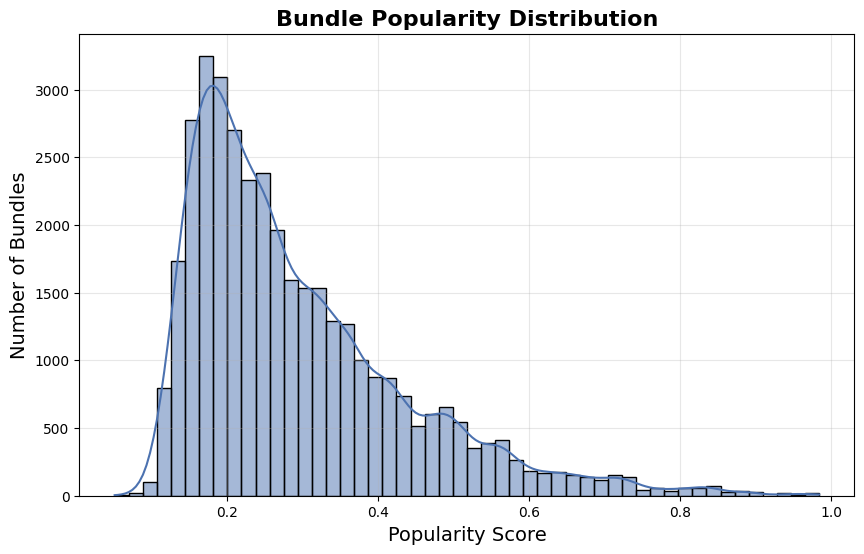

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data_pop['popularity_score'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [31]:
data.loc[:, 'popularity'] = data_pop['popularity_score'].values

In [32]:
if PercentileCategorization:
    p40 = data['popularity'].quantile(0.40)
    p80 = data['popularity'].quantile(0.80)
    data['popularity_category'] = pd.cut(
        data['popularity'],
        bins=[-float('inf'), p40, p80, float('inf')],
        labels=["Unpopular", "Popular", "Very Popular"],
        include_lowest=True
    )

    def popularity_category(score):
        if score >= p80:
            return "Very Popular"     # top 20%
        elif score >= p40:
            return "Popular"          # middle 40%
        else:
            return "Unpopular"        # bottom 40%

    data['popularity_category'] = data['popularity'].apply(popularity_category)
    print(data['popularity_category'].value_counts())

popularity_category
Popular         14902
Unpopular       14902
Very Popular     7451
Name: count, dtype: int64


In [129]:
# Detemine the best thresholds based on Gaussian Mixture
if not PercentileCategorization:
    scores = data_pop["popularity_score"].values.reshape(-1, 1)

    # Fit GMM
    gmm = GaussianMixture(n_components=3, random_state=42).fit(scores)
    labels = gmm.predict(scores)
    probs = gmm.predict_proba(scores)
    means = gmm.means_.flatten()
    std_devs = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_.flatten()

    # Sort components by mean
    order = np.argsort(means)
    means = means[order]
    std_devs = std_devs[order]
    weights = weights[order]

    thresholds = np.sort(gmm.means_.flatten())
    print("derived thresholds:", thresholds)

    # Plot 1: Distribution with individual components
    x_axis = np.linspace(scores.min(), scores.max(), 500).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    pdf = np.exp(logprob)

    colors = ['red', 'green', 'blue']
    component_names = ['Low Popularity', 'Medium Popularity', 'High Popularity']

    thresholds = []
    for i in range(len(means)-1):
        threshold = (means[i] + means[i+1]) / 2
        thresholds.append(threshold)

    # Create comprehensive figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Enhanced distribution with decision boundaries
    ax1.hist(scores, bins=50, alpha=0.3, density=True, color='lightblue', edgecolor='black')
    ax1.plot(x_axis, pdf, 'k-', linewidth=2, label='GMM Fit')

    # Add decision boundaries
    for i, threshold in enumerate(thresholds):
        ax1.axvline(threshold, color='red', linestyle='--', linewidth=2, 
                    label=f'Boundary {i+1}: {threshold:.2f}')

    ax1.set_title('Distribution with Decision Boundaries', fontweight='bold')
    ax1.set_xlabel('Popularity Score')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Component probabilities
    for i, (color, name) in enumerate(zip(colors, component_names)):
        ax2.hist(probs[:, order[i]], bins=30, alpha=0.6, color=color, label=name)
    ax2.set_title('Assignment Probabilities by Component', fontweight='bold')
    ax2.set_xlabel('Probability')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Summary statistics
    categories = component_names
    counts = [np.sum(labels == order[i]) for i in range(3)]
    percentages = [count/len(scores)*100 for count in counts]

    bars = ax3.bar(categories, counts, color=colors, alpha=0.7)
    ax3.set_title('Item Count by Popularity Category', fontweight='bold')
    ax3.set_ylabel('Number of Items')

    # Add percentage labels on bars
    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{percentage:.1f}%', ha='center', va='bottom')

    # Plot 4: Statistical summary
    stats_data = {
        'Mean': means,
        'Std Dev': std_devs,
        'Weight': weights
    }

    ax4.axis('off')
    table_data = [[f'{val:.3f}' for val in stats_data[key]] for key in stats_data]
    table = ax4.table(cellText=table_data,
                    rowLabels=list(stats_data.keys()),
                    colLabels=component_names,
                    cellLoc='center',
                    loc='center',
                    bbox=[0.1, 0.3, 0.8, 0.4])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax4.set_title('GMM Component Statistics', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [130]:
if  not PercentileCategorization:
    threshold_low = (means[0] + means[1]) / 2   # midpoint between first and second mean
    threshold_high = (means[1] + means[2]) / 2  # midpoint between second and third mean

    print("Thresholds for categories:", threshold_low, threshold_high)

    def gmm_category(score):
        if score < threshold_low:
            return "unpopular"
        elif score < threshold_high:
            return "popular"
        else:
            return "very popular"
        
    data["popularity_category"] = data["popularity"].apply(gmm_category)
    print(data["popularity_category"].value_counts())

In [33]:
data.sort_values(by='popularity', ascending=False)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite,popularity,popularity_category
33852,36,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.908463e+08,954233,...,16.0,0.0,1 days,24.0,summer,9.991916e-02,9.991916e+00,0,0.983913,Very Popular
34849,37,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.877384e+08,938692,...,16.0,0.0,1 days,24.0,summer,9.988187e-02,9.988187e+00,0,0.983402,Very Popular
39153,41,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.899620e+08,949812,...,16.0,0.0,1 days,24.0,autumn,9.825615e-02,9.825615e+00,0,0.982215,Very Popular
35667,38,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.850800e+08,925401,...,16.0,0.0,1 days,24.0,summer,9.915201e-02,9.915201e+00,0,0.982182,Very Popular
37749,40,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.904338e+08,952171,...,16.0,0.0,1 days,24.0,autumn,9.744222e-02,9.744222e+00,0,0.981401,Very Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24364,26,2025,80092,Forfait 16Min vers Autres (+2min vers MTN) 3 J...,BUNDLE_VOICE,300.0,CHARGED,STAFF,1.000000e+00,1,...,19.0,0.0,3 days,72.0,spring,5.689136e-10,5.689136e-08,0,0.072799,Unpopular
24065,26,2025,80094,Forfait 50Min vers Autres (+4min vers MTN) 15 ...,BUNDLE_VOICE,775.0,CHARGED,STAFF,1.000000e+00,1,...,50.0,0.0,15 days,360.0,spring,5.689136e-10,5.689136e-08,0,0.071915,Unpopular
29491,31,2025,37340,Forfait jeu video 7 jours@1000F,BUNDLE_DATA,1000.0,CHARGED,PREPAID,1.000000e+00,1,...,0.0,0.0,7 days,168.0,summer,5.267746e-10,5.267746e-08,0,0.062009,Unpopular
14419,16,2025,9031,100 SMS vers MTN ou 30 vers autre 3 jours@122F,BUNDLE_SMS,122.0,CHARGED,STAFF,1.100000e-01,1,...,0.0,100.0,3 days,72.0,spring,6.472747e-11,6.472747e-09,0,0.051414,Unpopular


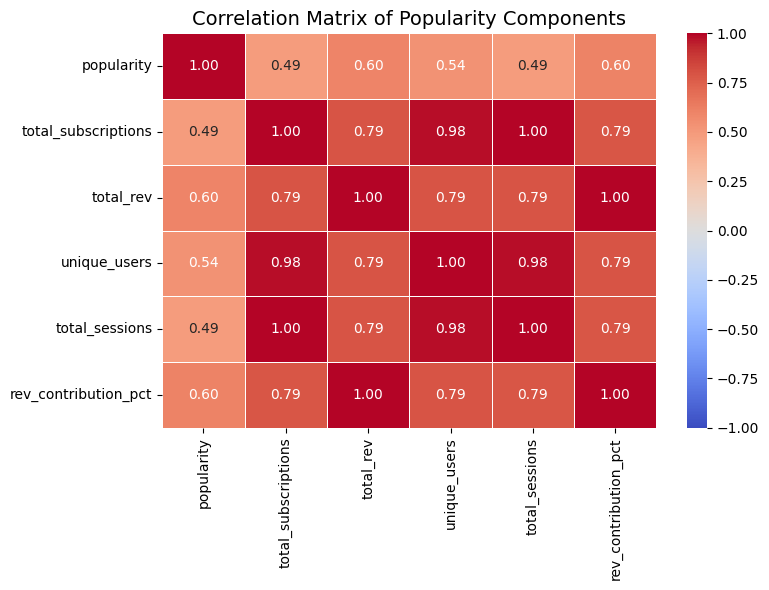

In [34]:
corr = data[['popularity','total_subscriptions','total_rev','unique_users','total_sessions', 'rev_contribution_pct']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,        
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Popularity Components", fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='total_subscriptions',
    y='total_rev',
    z='popularity',
    color='unique_users',
    size='unique_users',
    hover_name='bundle_name'
)

fig.show()

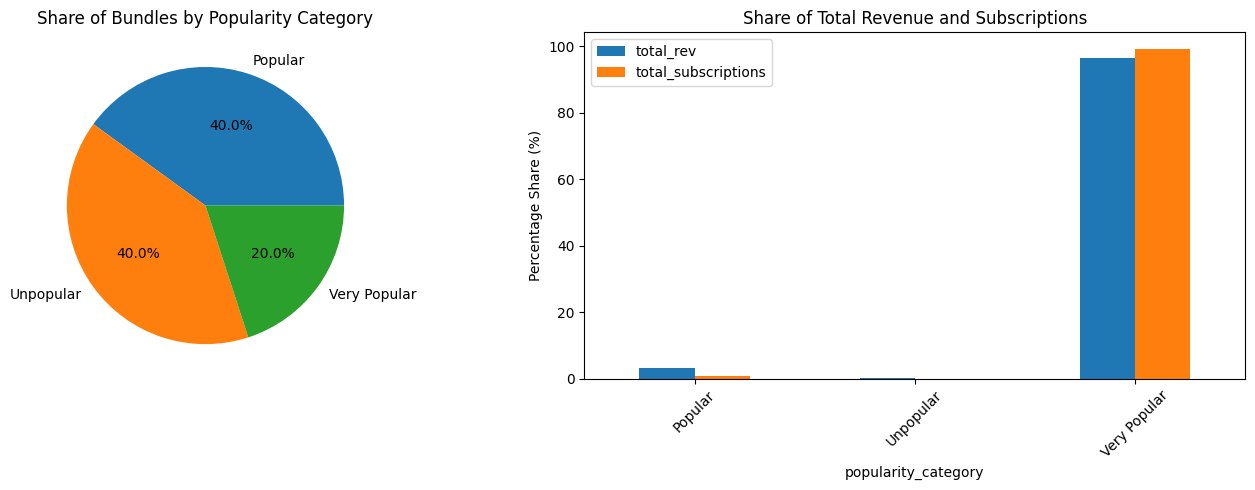

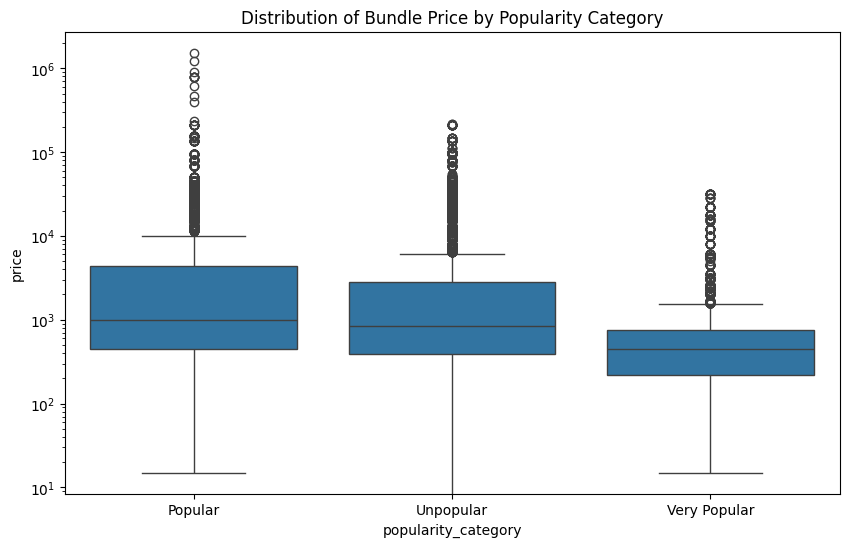

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data['popularity_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Bundles by Popularity Category')
ax1.set_ylabel('')

summary_df = data.groupby('popularity_category').agg({
    'total_rev': 'sum',
    'total_subscriptions': 'sum'
}).apply(lambda x: 100 * x / x.sum()) 

summary_df.plot.bar(ax=ax2, title='Share of Total Revenue and Subscriptions')
ax2.set_ylabel('Percentage Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='popularity_category', y='price')
plt.yscale('log') 
plt.title('Distribution of Bundle Price by Popularity Category')
plt.show()

In [37]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite,popularity,popularity_category
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0,0.239489,Popular
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0,0.185619,Unpopular
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0,0.138485,Unpopular
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0,0.382934,Popular
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1,0.240538,Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,...,0.0,300.0,5 days,120.0,autumn,2.562876e-04,0.025629,0,0.372036,Popular
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,525.00,1,...,43.0,0.0,7 days,168.0,autumn,5.312009e-07,0.000053,0,0.160138,Unpopular
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,...,15.0,0.0,30 days,720.0,autumn,3.034422e-06,0.000303,0,0.156588,Unpopular
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,...,0.0,0.0,7 days,168.0,autumn,1.669489e-06,0.000167,0,0.179641,Unpopular


## Popularity Regression Model 

In [38]:
X = data[
    [
        "week_number", "season", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours",
        "is_illimite"
    ]
].copy()
 
y = data["popularity"].astype(float)

assert len(X) == len(y)

In [ ]:
groups = X["bundle_name"]

# Create the group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 912
Testing bundles: 49
Overlap: 0


In [40]:
def feature_engineering_fit(df, y):
    df = df.copy()
    # SAFETY: drop target if present
    if "popularity" in df.columns:
        df = df.drop(columns=["popularity"])
        
    cat_cols = ["bundle_type", "season", "usage_type", "service_class_category"]

    # week features
    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # target encoding: FIT ON TRAIN ONLY
    te = TargetEncoder()
    df[cat_cols] = te.fit_transform(df[cat_cols], y)

    # text embedding
    st_model = SentenceTransformer("all-MiniLM-L6-v2")
    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    pca = PCA(n_components=32, random_state=42)
    name_emb_pca = pca.fit_transform(name_emb)

    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    # select numeric features
    numeric_df = df.select_dtypes(include=[float, int]).copy()
    scaler = StandardScaler()
    X = scaler.fit_transform(numeric_df)

    X = pd.DataFrame(X, columns=numeric_df.columns)

    return X, te, st_model, pca, scaler, numeric_df.columns.tolist()


def feature_engineering_apply(df, te, st_model, pca, scaler, numeric_cols):
    df = df.copy()
    cat_cols = ["bundle_type", "season", "usage_type", "service_class_category"]

    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # use te.transform (NO y)
    df[cat_cols] = te.transform(df[cat_cols])

    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    name_emb_pca = pca.transform(name_emb)
    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    numeric_df = df[numeric_cols].copy()
    X = scaler.transform(numeric_df)
    X = pd.DataFrame(X, columns=numeric_cols)

    return X

#def add_value_features(df):
#    df = df.copy()
#    eps = 1e-6

#    df["price_per_mb"]  = df["price"] / (df["configured_volume_mb"]  + eps)
#    df["price_per_min"] = df["price"] / (df["configured_volume_min"] + eps)
#    df["price_per_sms"] = df["price"] / (df["configured_volume_sms"] + eps)

    # Handle infs/NaNs
#    for col in ["price_per_mb", "price_per_min", "price_per_sms"]:
#        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
#        df[col] = df[col].fillna(df[col].max())

    # Optional log versions
#    for col in ["price", "configured_volume_mb", "configured_volume_min",
#                "configured_volume_sms", "validity_hours"]:
#        df[f"log_{col}"] = np.log1p(df[col])

#    return df


#X_train_ext = add_value_features(X_train)
#X_test_ext  = add_value_features(X_test)

X_train_fe, te, st_model, pca, scaler, numeric_cols = feature_engineering_fit(
    X_train, y_train
)
X_test_fe = feature_engineering_apply(
    X_test, te, st_model, pca, scaler, numeric_cols
)


In [41]:
X_train_fe

,week_number,season,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,...,name_emb_22,name_emb_23,name_emb_24,name_emb_25,name_emb_26,name_emb_27,name_emb_28,name_emb_29,name_emb_30,name_emb_31
0,-1.750659,-1.204118,0.172424,-0.036727,-1.383348,0.635543,-0.175609,-0.309204,-0.095796,1.487029,...,0.034853,-1.054202,-2.219539,0.854151,1.930497,-1.414411,0.570254,0.535382,-0.034148,0.571511
1,-1.750659,-1.094289,-2.348452,-0.224734,0.134064,0.644113,-0.175609,-0.291201,-0.095796,1.487029,...,1.663662,-1.521134,-2.102654,0.957981,1.563906,1.086171,-0.297983,0.940709,0.152315,-0.553703
2,-1.750659,-1.006993,0.195508,2.241630,0.511686,0.645737,-0.175609,-0.309204,-0.095796,1.487029,...,0.621569,1.087572,-0.995886,-2.906252,-1.376192,2.218750,0.282079,-0.380803,0.016072,-0.165094
3,-1.750659,-1.094289,-2.348452,-0.160416,0.134064,0.644113,-0.175609,-0.219189,-0.095796,1.487029,...,-0.903542,1.396662,-0.702765,-0.468757,-0.341683,-0.255339,0.766917,1.071686,-0.909649,-1.352401
4,-1.750659,-1.006993,-2.352653,-0.205439,0.511686,0.645737,-0.175609,-0.291201,-0.095796,1.487029,...,-1.380684,3.313439,0.549901,-2.068391,0.422998,1.958461,0.888438,0.225687,2.276454,1.118480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35078,1.668244,0.926426,1.022814,-0.218055,-0.756755,0.640270,-0.175609,-0.309204,8.895943,-0.464706,...,-0.866881,0.354958,1.528528,-1.191474,2.016734,-1.517490,0.249106,-1.138991,-1.514442,0.219541
35079,1.668244,0.926426,0.718440,-0.208655,-0.756755,0.640270,-0.175609,0.077861,-0.095796,-0.308567,...,2.738697,0.271175,0.023658,-1.192294,-0.043518,-2.236903,1.662503,-0.796664,-0.115895,1.572724
35080,1.668244,1.309173,-2.342260,-0.086252,-1.383348,0.635543,-0.175609,-0.174181,-0.095796,1.487029,...,-0.168999,-0.063934,0.503674,-1.916861,-1.110370,-1.924520,-1.234815,-0.447110,-0.117082,0.637540
35081,1.668244,0.909048,0.193856,-0.207418,0.134064,-1.249640,-0.170691,-0.309204,-0.095796,-0.308567,...,-0.218967,2.988865,0.615297,1.791390,1.551503,1.726698,-1.720309,-0.909295,0.772442,-2.650284


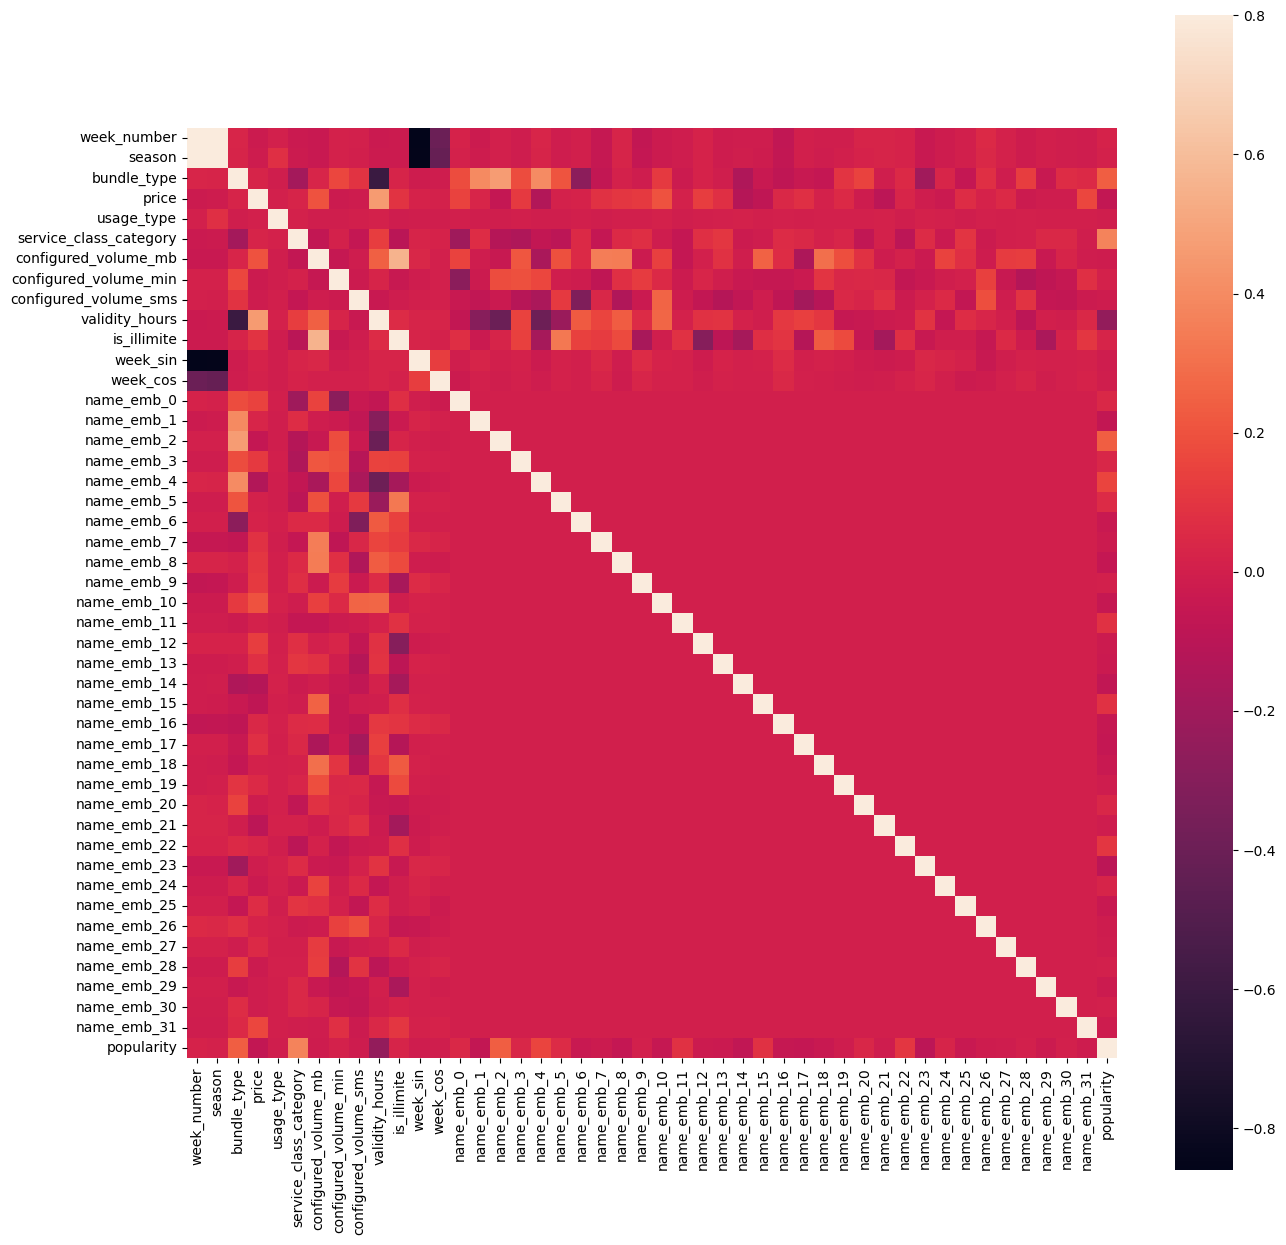

In [42]:
train_data = X_train_fe.copy()
train_data['popularity'] = y_train

C_mat = train_data.corr()
fig = plt.figure(figsize = (15,15))

sns.heatmap(C_mat, vmax = .8, square = True)
plt.show()
del train_data

In [43]:
X_train_ready = X_train_fe.values
X_test_ready = X_test_fe.values

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ),
    "AdaBoost": AdaBoostRegressor(n_estimators=200, random_state=42),
    "SVR (RBF Kernel)": SVR(C=2.0, epsilon=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "LGBMRegressor": lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
    ),
}

results = []
for name, model in tqdm(models.items(), total=len(models)):
    model.fit(X_train_ready, y_train)
    y_pred = model.predict(X_test_ready)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)

    results.append([name, rmse, mae, mape, r2, evs])

results_df = pd.DataFrame(
    results, columns=["Model", "RMSE", "MAE", "MAPE", "R2", "Explained Variance"]
).sort_values("RMSE")
results_df

 80%|████████  | 8/10 [02:08<00:32, 16.23s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8961
[LightGBM] [Info] Number of data points in the train set: 38884, number of used features: 45
[LightGBM] [Info] Start training from score 0.289146


100%|██████████| 10/10 [02:09<00:00, 12.97s/it]


,Model,RMSE,MAE,MAPE,R2,Explained Variance
9,LGBMRegressor,0.087713,0.061898,0.198856,0.610057,0.665880
5,Gradient Boosting,0.089803,0.065313,0.214785,0.591255,0.668945
4,Random Forest,0.094052,0.068460,0.216121,0.551662,0.647841
6,AdaBoost,0.097286,0.074620,0.269760,0.520295,0.531604
0,Linear Regression,0.099871,0.075021,0.268111,0.494463,0.526232
1,Ridge Regression,0.099871,0.075022,0.268111,0.494462,0.526229
2,Lasso Regression,0.100101,0.075651,0.270568,0.492137,0.520073
7,SVR (RBF Kernel),0.103242,0.077039,0.285169,0.459761,0.489953
8,KNN Regressor,0.105614,0.073881,0.252819,0.434652,0.440267
3,Decision Tree,0.110732,0.081981,0.269141,0.378534,0.471036


In [59]:
groups_train = X_train["bundle_name"] 

lgbm_base = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
)

gkf = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    lgbm_base,
    X_train_fe,
    y_train,
    cv=gkf.split(X_train_fe, y_train, groups_train),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

print("CV RMSE mean:", -cv_scores.mean(), "std:", cv_scores.std())

CV RMSE mean: 0.10145206742444994 std: 0.0035129128180225806


In [60]:
param_dist = {
    "num_leaves": [31, 63, 127, 255],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "n_estimators": [500, 800, 1200, 1500],
    "min_child_samples": [10, 20, 40, 80],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.3, 0.5],
    "reg_lambda": [0.0, 0.1, 0.3, 0.5],
}

lgbm = lgb.LGBMRegressor(random_state=42)
gkf = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=gkf.split(X_train_fe, y_train, groups_train),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_fe, y_train)
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

best_lgbm = search.best_estimator_
y_pred_test = best_lgbm.predict(X_test_fe)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8967
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 44
[LightGBM] [Info] Start training from score 0.343631
Best params: {'subsample': 0.8, 'reg_lambda': 0.3, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 40, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
Best CV RMSE: 0.09921619720401999
Test RMSE: 0.09803518556973845


In [44]:
my_lgbm = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=-1,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=0.3,
        random_state=42,
        min_child_samples=40       
)
my_lgbm.fit(X_train_ready, y_train)
y_pred = my_lgbm.predict(X_test_ready)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
print(f"rmse: {rmse}, mae: {mae}, mape: {mape}, r2: {r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8959
[LightGBM] [Info] Number of data points in the train set: 35083, number of used features: 45
[LightGBM] [Info] Start training from score 0.291628
rmse: 0.0999626639631209, mae: 0.06635151008336543, mape: 0.21694812387442303, r2: 0.63142564315085


In [ ]:
# Try LGBMRegressor with Cross-Validation
groups = X_train["bundle_name"]          # group by bundle_name
gkf = GroupKFold(n_splits=5)

rmse_scores = []
mae_scores = []
r2_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_ready, y_train, groups=groups), 1):
    X_tr, X_val = X_train_ready[tr_idx], X_train_ready[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=0.3,
        random_state=42,
        min_child_samples=80
    )
    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)
    r2  = r2_score(y_val, y_val_pred)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold}: RMSE={rmse:.5f}, MAE={mae:.5f}, R²={r2:.5f}")

print(f"\nCV RMSE: mean={np.mean(rmse_scores):.5f}, std={np.std(rmse_scores):.5f}")
print(f"CV MAE:  mean={np.mean(mae_scores):.5f}, std={np.std(mae_scores):.5f}")
print(f"CV R²:   mean={np.mean(r2_scores):.5f}, std={np.std(r2_scores):.5f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8866
[LightGBM] [Info] Number of data points in the train set: 31391, number of used features: 43
[LightGBM] [Info] Start training from score 0.423551
Fold 1: RMSE=0.01483, MAE=0.09079, R²=0.53460
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8866
[LightGBM] [Info] Number of data points in the train set: 31391, number of used features: 43
[LightGBM] [Info] Start training from score 0.426665
Fold 2: RMSE=0.01476, MAE=0.09017, R²=0.49847
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8873
[LightGBM] [Info] Number of 

In [45]:
model_cat = CatBoostRegressor(
    iterations=5000,
    depth=10,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    task_type="GPU",  # if available
    one_hot_max_size=4,      # improves rare-category handling
    boosting_type='Ordered', # safer, less overfitting
)

model_cat.fit(
    X_train_fe, y_train,
    eval_set=(X_test_fe, y_test),
    verbose=200
)


0:	learn: 0.1402109	test: 0.1638297	best: 0.1638297 (0)	total: 140ms	remaining: 11m 41s
200:	learn: 0.0497528	test: 0.1042643	best: 0.1041765 (198)	total: 14.3s	remaining: 5m 42s
400:	learn: 0.0459469	test: 0.1035737	best: 0.1034990 (339)	total: 24.1s	remaining: 4m 36s
600:	learn: 0.0444649	test: 0.1035375	best: 0.1034990 (339)	total: 33.5s	remaining: 4m 5s
800:	learn: 0.0435719	test: 0.1033132	best: 0.1033027 (797)	total: 44.8s	remaining: 3m 55s
1000:	learn: 0.0424889	test: 0.1031976	best: 0.1031964 (999)	total: 56.8s	remaining: 3m 46s
1200:	learn: 0.0418932	test: 0.1031722	best: 0.1031561 (1178)	total: 1m 3s	remaining: 3m 22s
1400:	learn: 0.0418080	test: 0.1032035	best: 0.1031561 (1178)	total: 1m 7s	remaining: 2m 53s
1600:	learn: 0.0416124	test: 0.1031763	best: 0.1031561 (1178)	total: 1m 15s	remaining: 2m 39s
1800:	learn: 0.0414346	test: 0.1032084	best: 0.1031561 (1178)	total: 1m 21s	remaining: 2m 24s
2000:	learn: 0.0414200	test: 0.1032118	best: 0.1031561 (1178)	total: 1m 23s	remaini

In [46]:
y_pred = model_cat.predict(X_test_fe)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.5f}")
print(f"MAE:  {mae:.5f}")
print(f"R²:   {r2:.5f}")

RMSE: 0.10316
MAE:  0.06878
R²:   0.60750


In [43]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

dtrain = xgb.DMatrix(X_train_fe, label=y_train)
dtest  = xgb.DMatrix(X_test_fe,  label=y_test)

params = {
    'objective': 'reg:squarederror',   # regression
    'eval_metric': 'rmse',
    'eta': 0.05,                       # learning rate
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1.0,                     # L2 regularization
    'alpha': 0.0                       # L1 regularization
}

watchlist = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1500,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=100
)

# Make predictions
pred = model.predict(dtest)
print("R2:", r2_score(y_test, pred))


[0]	train-rmse:0.16863	test-rmse:0.18487
[100]	train-rmse:0.07116	test-rmse:0.12315
[200]	train-rmse:0.06055	test-rmse:0.12181
[221]	train-rmse:0.05912	test-rmse:0.12181
R2: 0.582587300316699


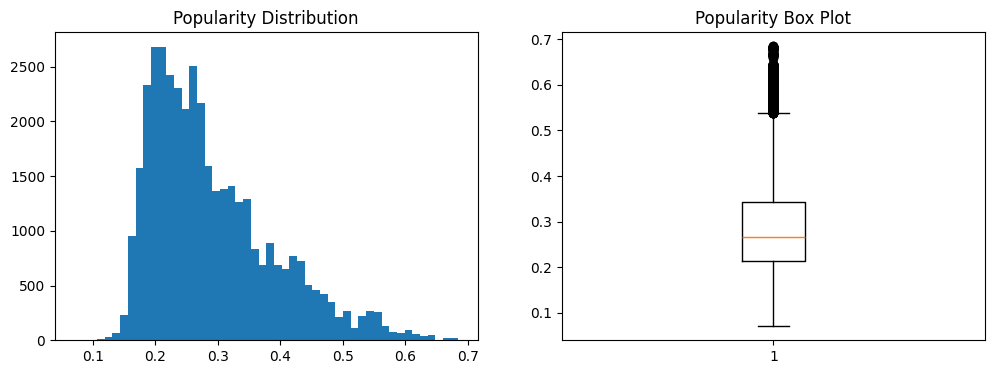

Skewness: 1.039
Kurtosis: 0.695


In [74]:
# First, analyze your target distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(np.log1p(y_train), bins=50)
plt.title('Popularity Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(np.log1p(y_train))
plt.title('Popularity Box Plot')
plt.show()

# Check if transformation is needed
from scipy import stats
print(f"Skewness: {stats.skew(np.log1p(y_train)):.3f}")
print(f"Kurtosis: {stats.kurtosis(np.log1p(y_train)):.3f}")

if abs(stats.skew(np.log1p(y_train))) > 1:
    y_train_transformed = np.log1p(np.log1p(y_train))  

* So far we trained different Regression Models and the best two model we got for now are:
        
    CatBoostRegressor

        - RMSE: 0.12052
        - MAE:  0.08956
        - R²:   0.59134

    LGBMRegressor:
        
        - rmse: 0.11879329338987099   
        - mae: 0.08696962565838265 
        - mape: 0.216701906381535
        - r2: 0.6029888475948855

    xgboost:

        - rmse: 0.10879329338987099   
        - mae: 0.09696962565838265 
        - mape: 0.116701906381535
        - r2: 0.582587300316699



## Ensebmle Learning
we will try to apply EL to get a better result based on our best two models,I will try simple Ensemble learning techniques like weighted average, then we will try more advanced ensemble learning techniques.

In [77]:
print("X train: ", X_train_fe.shape, " y train: ", y_train.shape)
print("X test: ", X_test_fe.shape, " y train: ", y_test.shape)

X train:  (39239, 44)  y train:  (39239,)
X test:  (2247, 44)  y train:  (2247,)


In [37]:
# Weighted Avg Ensemble Learning:
my_lgbm = lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=0.3,
        random_state=42,
        min_child_samples=80       
)
my_lgbm.fit(X_train_fe, y_train)
y_pred = my_lgbm.predict(X_test_fe)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
print("LGBMRegressor: ")
print(f"rmse: {rmse}, mae: {mae}, mape: {mape}, r2: {r2}")
print()

model_cat = CatBoostRegressor(
    iterations=5000,
    depth=10,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    task_type="GPU",  # if available
    one_hot_max_size=4,      # improves rare-category handling
    boosting_type='Ordered', # safer, less overfitting
)

model_cat.fit(
    X_train_fe, y_train,
    eval_set=(X_test_fe, y_test),
    verbose=200
)

y_pred = model_cat.predict(X_test_fe)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print("CatBoostRegressor: ")
print(f"rmse: {rmse}, mae: {mae}, r2: {r2}")


def weighted_avg_ensemble(pred1, pred2, w1=0.6, w2=0.4):
    """
    Returns a weighted ensemble of two prediction arrays.
    w1 and w2 should sum to 1.
    """
    return (w1 * pred1) + (w2 * pred2)


y_pred_lgbm = my_lgbm.predict(X_test_fe)
y_pred_cat  = model_cat.predict(X_test_fe)

y_pred_ensemble = weighted_avg_ensemble(y_pred_lgbm, y_pred_cat, 
                                        w1=0.65, 
                                        w2=0.35)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae  = mean_absolute_error(y_test, y_pred_ensemble)
r2   = r2_score(y_test, y_pred_ensemble)


print("Ensemble Learning of weighted avg: ")
print(f"RMSE: {rmse:.5f}")
print(f"Ensemble MAE:  {mae:.5f}")
print(f"Ensemble R²:   {r2:.5f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8945
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 43
[LightGBM] [Info] Start training from score 0.424516
LGBMRegressor: 
rmse: 0.1183375208568481, mae: 0.0862158207315733, mape: 0.21572110380022874, r2: 0.6060294175707697

0:	learn: 0.1706551	test: 0.1870313	best: 0.1870313 (0)	total: 76.2ms	remaining: 6m 21s
200:	learn: 0.0653452	test: 0.1238569	best: 0.1238569 (200)	total: 14.9s	remaining: 5m 55s
400:	learn: 0.0601415	test: 0.1224542	best: 0.1224542 (400)	total: 28.3s	remaining: 5m 24s
600:	learn: 0.0582824	test: 0.1221440	best: 0.1219893 (508)	total: 37.5s	remaining: 4m 34s
800:	learn: 0.0578816	test: 0.1220239	best: 0.1219893 (508)	total: 42.1s	remaining: 3m 40s
1000:	learn: 0.0575087	test: 0.1218881	best: 0.1218569 (923)	total: 46.6s	remaining: 3m 

* No improvement with that, We will try more advanced techniques in Ensemble Learning:

In [ ]:
# Stacking Ensemble Learning:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# Base models
lgbm_model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=0.3,
    random_state=42,
    min_child_samples=80  
)

cat_model = CatBoostRegressor(
    iterations=5000,
    depth=10,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    task_type="GPU",
    one_hot_max_size=4,
    boosting_type='Ordered',
    verbose=0
)

# Meta model
meta_model = Ridge(alpha=1.0)
stacked_model = StackingRegressor(
    estimators=[
        ('lgbm', lgbm_model),
        ('cat', cat_model)
    ],
    final_estimator=meta_model,
    passthrough=False,   # only pass predictions to meta-model
    cv=5                 # generates out-of-fold preds properly
)

stacked_model.fit(X_train_fe, y_train)
y_pred_stack = stacked_model.predict(X_test_fe)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae  = mean_absolute_error(y_test, y_pred_stack)
r2   = r2_score(y_test, y_pred_stack)

print(f"Stacked RMSE: {rmse:.5f}")
print(f"Stacked MAE:  {mae:.5f}")
print(f"Stacked R²:   {r2:.5f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8945
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 43
[LightGBM] [Info] Start training from score 0.424516
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8915
[LightGBM] [Info] Number of data points in the train set: 31391, number of used features: 43
[LightGBM] [Info] Start training from score 0.425234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8928
[LightGBM] [Info] Number of data points in the train set: 31391, number of used features: 43
[LightGBM] [Info] Start tra

* we will try differnet approach.

### Nerual Network Regression


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class BundleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = BundleDataset(X_train_fe, y_train)
test_ds = BundleDataset(X_test_fe, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


import torch.nn as nn


class PopularityNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)  # regression output
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_fe.shape[1]
net = PopularityNet(input_dim)

import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

device = "cuda" if torch.cuda.is_available() else "cpu"
net.to(device)

num_epochs = 200

for epoch in range(num_epochs):
    net.train()
    train_loss = 0
    
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = net(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(Xb)

    train_loss /= len(train_loader.dataset)
    scheduler.step(train_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}")



Epoch 1/500 | Train Loss: 0.0288
Epoch 2/500 | Train Loss: 0.0114
Epoch 3/500 | Train Loss: 0.0094
Epoch 4/500 | Train Loss: 0.0082
Epoch 5/500 | Train Loss: 0.0075
Epoch 6/500 | Train Loss: 0.0070
Epoch 7/500 | Train Loss: 0.0066
Epoch 8/500 | Train Loss: 0.0062
Epoch 9/500 | Train Loss: 0.0059
Epoch 10/500 | Train Loss: 0.0057
Epoch 11/500 | Train Loss: 0.0056
Epoch 12/500 | Train Loss: 0.0054
Epoch 13/500 | Train Loss: 0.0053
Epoch 14/500 | Train Loss: 0.0051
Epoch 15/500 | Train Loss: 0.0051
Epoch 16/500 | Train Loss: 0.0050
Epoch 17/500 | Train Loss: 0.0049
Epoch 18/500 | Train Loss: 0.0048
Epoch 19/500 | Train Loss: 0.0048
Epoch 20/500 | Train Loss: 0.0047
Epoch 21/500 | Train Loss: 0.0046
Epoch 22/500 | Train Loss: 0.0046
Epoch 23/500 | Train Loss: 0.0045
Epoch 24/500 | Train Loss: 0.0044
Epoch 25/500 | Train Loss: 0.0043
Epoch 26/500 | Train Loss: 0.0044
Epoch 27/500 | Train Loss: 0.0043
Epoch 28/500 | Train Loss: 0.0042
Epoch 29/500 | Train Loss: 0.0042
Epoch 30/500 | Train Lo

In [82]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

net.eval()
preds_list = []
true_list = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = net(Xb).cpu().numpy()
        preds_list.append(preds)
        true_list.append(yb.numpy())

preds = np.vstack(preds_list).reshape(-1)
true = np.vstack(true_list).reshape(-1)

r2 = r2_score(true, preds)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 0.1182107709377294
R²: 0.5249786376953125


## Popularity Classifier Model 

In [101]:
X = data[
    [
        "week_number", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
].copy()
 
y = data["popularity_category"].astype(str)

assert len(X) == len(y)

In [102]:
groups = X["bundle_name"]

# Create the group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# Optional: check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 989
Testing bundles: 53
Overlap: 0


In [104]:
num_cols = ["week_number", "price", "configured_volume_mb", 
            "configured_volume_min", "configured_volume_sms", "validity_hours"]


cat_cols = ["bundle_type", "usage_type", "service_class_category"]
df_encoded = X_train.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# Sentence Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
name_emb = st_model.encode(df_encoded["bundle_name"].tolist())

# PCA on embeddings
pca = PCA(n_components=32)
name_emb_pca = pca.fit_transform(name_emb)

# Add PCA components as features
for i in range(name_emb_pca.shape[1]):
    df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]

# Scale numeric features
numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_train_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

# Transform test data using **trained encoders/scalers/PCA**
df_test_encoded = X_test.copy()
df_test_encoded[cat_cols] = encoder.transform(df_test_encoded[cat_cols])

# Bundle name embeddings for test set
name_emb_test = st_model.encode(df_test_encoded["bundle_name"].tolist())
name_emb_test_pca = pca.transform(name_emb_test)
for i in range(name_emb_test_pca.shape[1]):
    df_test_encoded[f"name_emb_{i}"] = name_emb_test_pca[:, i]

numeric_df_test = df_test_encoded.select_dtypes(include=[float, int]).copy()
X_test_ready = pd.DataFrame(scaler.transform(numeric_df_test), columns=numeric_df_test.columns)

In [ ]:
num_cols = ["week_number", "price", "configured_volume_mb", 
            "configured_volume_min", "configured_volume_sms", "validity_hours"]


cat_cols = ["bundle_type", "usage_type", "service_class_category"]
df_encoded = X_train.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# Sentence Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
name_emb = st_model.encode(df_encoded["bundle_name"].tolist())

# PCA on embeddings
pca = PCA(n_components=32)
name_emb_pca = pca.fit_transform(name_emb)

# Add PCA components as features
for i in range(name_emb_pca.shape[1]):
    df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]


df_encoded['week_sin'] = np.sin(2 * np.pi * df_encoded['week_number'] / 52)
df_encoded['week_cos'] = np.cos(2 * np.pi * df_encoded['week_number'] / 52)

# Scale numeric features
numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_train_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

# ----------------------
# Transform test data using **trained encoders/scalers/PCA**
df_test_encoded = X_test.copy()
df_test_encoded[cat_cols] = encoder.transform(df_test_encoded[cat_cols])

# Bundle name embeddings for test set
name_emb_test = st_model.encode(df_test_encoded["bundle_name"].tolist())
name_emb_test_pca = pca.transform(name_emb_test)
for i in range(name_emb_test_pca.shape[1]):
    df_test_encoded[f"name_emb_{i}"] = name_emb_test_pca[:, i]

numeric_df_test = df_test_encoded.select_dtypes(include=[float, int]).copy()
X_test_ready = pd.DataFrame(scaler.transform(numeric_df_test), columns=numeric_df_test.columns)

In [105]:
clf = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=0.3,
    class_weight='balanced',  # boosts rare classes
    random_state=42
)
clf.fit(X_train_ready, y_train)

# Evaluate
y_pred = clf.predict(X_test_ready)
rr = classification_report(y_test, y_pred)
print(rr)

              precision    recall  f1-score   support

     Popular       0.76      0.63      0.69       825
   Unpopular       0.72      0.83      0.77       867
Very Popular       0.68      0.69      0.68       555

    accuracy                           0.72      2247
   macro avg       0.72      0.72      0.71      2247
weighted avg       0.73      0.72      0.72      2247



In [106]:
def predict_bundle_class(new_bundle, encoder, st_model, pca, scaler, clf):
    """
    Predict popularity category for a new bundle.
    
    Parameters
    ----------
    new_bundle : dict or pandas.DataFrame
        The new bundle's feature values.
    encoder : OrdinalEncoder
        Fitted ordinal encoder for categorical features.
    st_model : SentenceTransformer
        Fitted sentence-transformer model.
    pca : PCA
        Fitted PCA transformer for name embeddings.
    scaler : StandardScaler
        Fitted scaler for numeric + embedding features.
    clf : HistGradientBoostingClassifier
        Trained classifier.

    Returns
    -------
    str
        Predicted popularity class.
    """
    if isinstance(new_bundle, dict):
        df_new = pd.DataFrame([new_bundle])
    else:
        df_new = new_bundle.copy()

    cat_cols = ["bundle_type", "usage_type", "service_class_category"]
    num_cols = [
        "week_number", "price", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
    df_new[cat_cols] = encoder.transform(df_new[cat_cols])

    name_emb = st_model.encode(df_new["bundle_name"].tolist())
    name_emb_pca = pca.transform(name_emb)

    for i in range(name_emb_pca.shape[1]):
        df_new[f"name_emb_{i}"] = name_emb_pca[:, i]
    numeric_df = df_new[[col for col in df_new.columns if df_new[col].dtype != "object"]].copy()
    X_scaled = scaler.transform(numeric_df)
    pred = clf.predict(X_scaled)[0]
    return pred



new_bundle = {
    "week_number": 5,
    "bundle_name": "Mega Social Plus",
    "bundle_type": "data",
    "price": 30.5,
    "usage_type": "youth",
    "service_class_category": "prepaid",
    "configured_volume_mb": 1500,
    "configured_volume_min": 30,
    "configured_volume_sms": 50,
    "validity_hours": 72
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Unpopular


In [36]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Maxivoice 19Mins jour@220F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 220.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Very Popular


In [37]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Maxivoice 19Mins 1000MB jour@2000F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 2000.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 1000.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Popular


In [38]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Zone A and B NDAKO  550GB  30 Jours@26500F",
    "bundle_type": "BUNDLE_DATA",
    "price": 26500.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Popular


In [39]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Very Popular


In [ ]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "STAFF",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Unpopular
